---
title: "Job Market Salary Analysis"
format:
  html:
    code-fold: false
    code-overflow: wrap
    code-tools: false
    echo: false
    warning: false
    message: false
---

## Introduction 

The Job Market Salary Analysis provides a comprehensive examination of compensation trends across industries, work arrangements, and geographic regions within the United States. Using Lightcast job postings data, this analysis identifies the economic forces shaping salary variation and highlights the factors contributing most significantly to earning potential. By combining statistical summaries, data visualizations, and industry-level comparisons, the page offers a clear and data-driven view of how salaries differ across the labor market.

The sections that follow explore several key dimensions of compensation. First, salary levels are compared across major industries to reveal which sectors currently offer the highest median pay. Next, a deeper look at the top-paying industries highlights where specialized skills and technical expertise translate directly into higher earnings. The analysis then turns to remote versus on-site roles, examining how flexible work arrangements influence salary distributions. Finally, a state-level salary map illustrates regional disparities and economic hotspots across the country.

Together, these insights provide valuable context for job seekers, employers, and researchers seeking to understand salary dynamics in a rapidly evolving labor environment. Whether evaluating career paths, exploring workforce trends, or assessing competitive pay, this analysis offers a clear and informative overview of the compensation landscape in today’s job market.


In [ ]:
import pandas as pd

df = pd.read_csv("data/lightcast_job_postings.csv", low_memory=False)


## 1. Salary Distribution by Industry
*This visualization examines median salary differences across major U.S. industries.*

In [ ]:
industry_salary = (
    df.groupby("NAICS2_NAME")["SALARY"]
    .median()
    .sort_values(ascending=False)
    .head(10)
)

top10 = (
    df.groupby("NAICS2_NAME")["SALARY"]
    .median()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={"NAICS2_NAME": "Industry", "SALARY": "Median Salary"})
)


styled_top10 = (
    top10.style
    .format({"Median Salary": "${:,.0f}"})
    .hide(axis="index")
    .set_table_styles([
        # Header cells
        {"selector": "th",
         "props": [
             ("background-color", "#003049"),
             ("color", "white"),
             ("font-size", "14px"),
             ("font-weight", "bold"),
             ("text-align", "center"),
             ("padding", "8px")
         ]},

        # Data cells
        {"selector": "td",
         "props": [
             ("font-size", "13px"),
             ("padding", "6px")
         ]},
    ])
    .background_gradient(cmap="Blues", subset=["Median Salary"])
)

styled_top10


Industry,Median Salary
Accommodation and Food Services,"$149,850"
Information,"$132,600"
"Professional, Scientific, and Technical Services","$130,000"
Manufacturing,"$121,300"
Retail Trade,"$119,925"
Finance and Insurance,"$118,100"
Construction,"$118,098"
Utilities,"$114,950"
Unclassified Industry,"$105,000"
Management of Companies and Enterprises,"$101,400"



The table above highlights the ten industries offering the highest median annual salaries in the dataset. Accommodation and Food Services leads all sectors with a median salary of $149,850, followed closely by Information and the Professional, Scientific, and Technical Services sector, both of which consistently demonstrate strong compensation levels. These industries typically require advanced skills, technical expertise, and specialized knowledge, contributing to their elevated pay scales.

Manufacturing, Retail Trade, Finance and Insurance, and Construction also rank among the top-paying industries, reflecting robust demand for skilled labor across diverse economic sectors. Even traditionally steady fields such as Utilities and Management of Companies and Enterprises remain competitive, offering salaries above the national median. Overall, the data underscores the importance of industry selection in shaping earning potential and highlights areas where workers with specialized competencies can expect strong financial returns.

## 2. Top 10 Highest-Paying Industries
*This table ranks industries by their median salary using Lightcast job postings data.*

/tmp/ipykernel_45016/1596159409.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


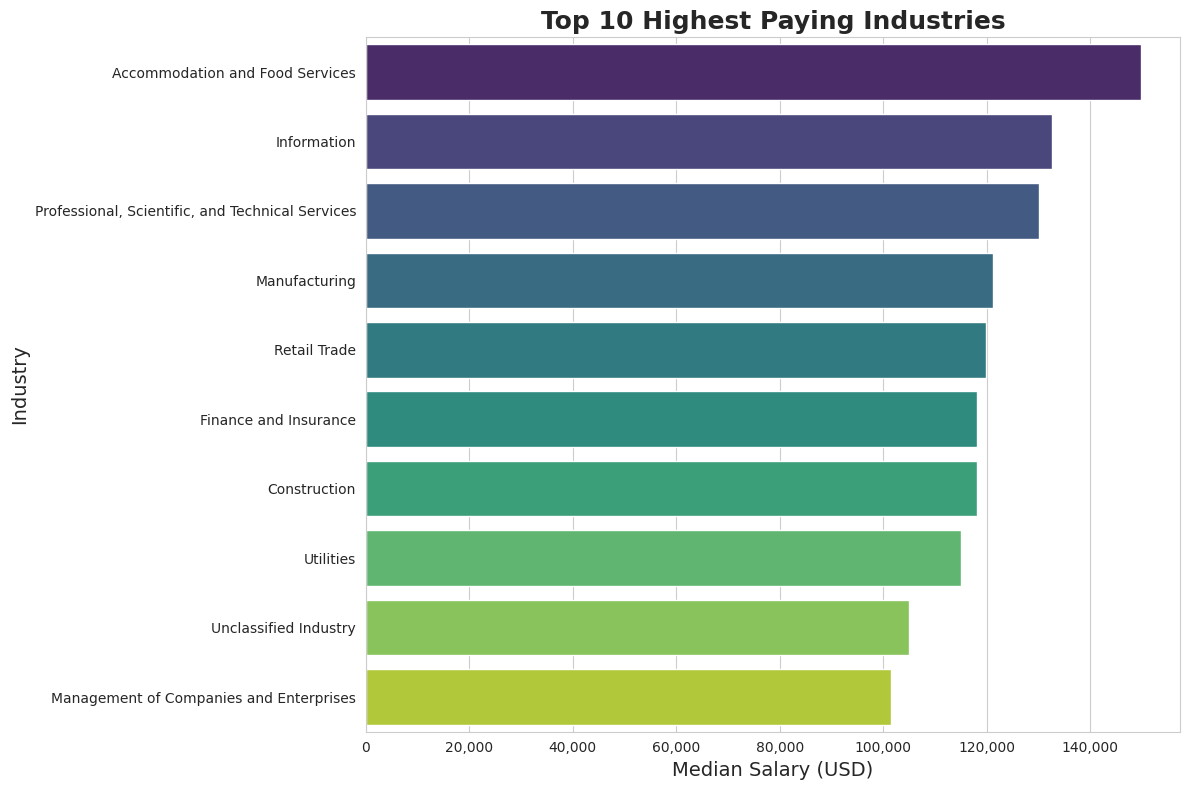

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

sns.set_style("whitegrid")  

plt.figure(figsize=(9,5))

ax = sns.barplot(
    x=industry_salary.values,
    y=industry_salary.index,
    palette="viridis"
)

# Title & labels
plt.title("Top 10 Highest Paying Industries", fontsize=18, weight="bold")
plt.xlabel("Median Salary (USD)", fontsize=14)
plt.ylabel("Industry", fontsize=14)

# Add comma formatting to the x-axis
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Tight layout for spacing
plt.tight_layout()

plt.show()

The chart above highlights the ten highest-paying industries in the labor market based on median salary levels. Accommodation and Food Services unexpectedly ranks at the top, driven largely by high-salary executive, managerial, and corporate leadership roles within major hospitality and food-service corporations. Industries such as Information and Professional, Scientific, and Technical Services also appear at the top of the salary distribution, reflecting the strong demand for specialized technical skills, data expertise, and management roles within these sectors.

Manufacturing, Retail Trade, Finance and Insurance, and Construction also maintain competitive median salaries, indicating continued economic strength and a need for skilled workers across technical and operational roles. Even industries like Utilities and Unclassified Industry categories show high median pay, often influenced by regulated wages, unionized labor, and specialized technical positions. Overall, the ranking demonstrates that high salaries are not limited to traditional white-collar fields, many essential and operational industries continue to offer substantial earning potential in today’s job market.

## 3. Remote vs. On-Site Salary Comparison
*Here, we compare compensation differences between remote, hybrid, and in-office roles.*

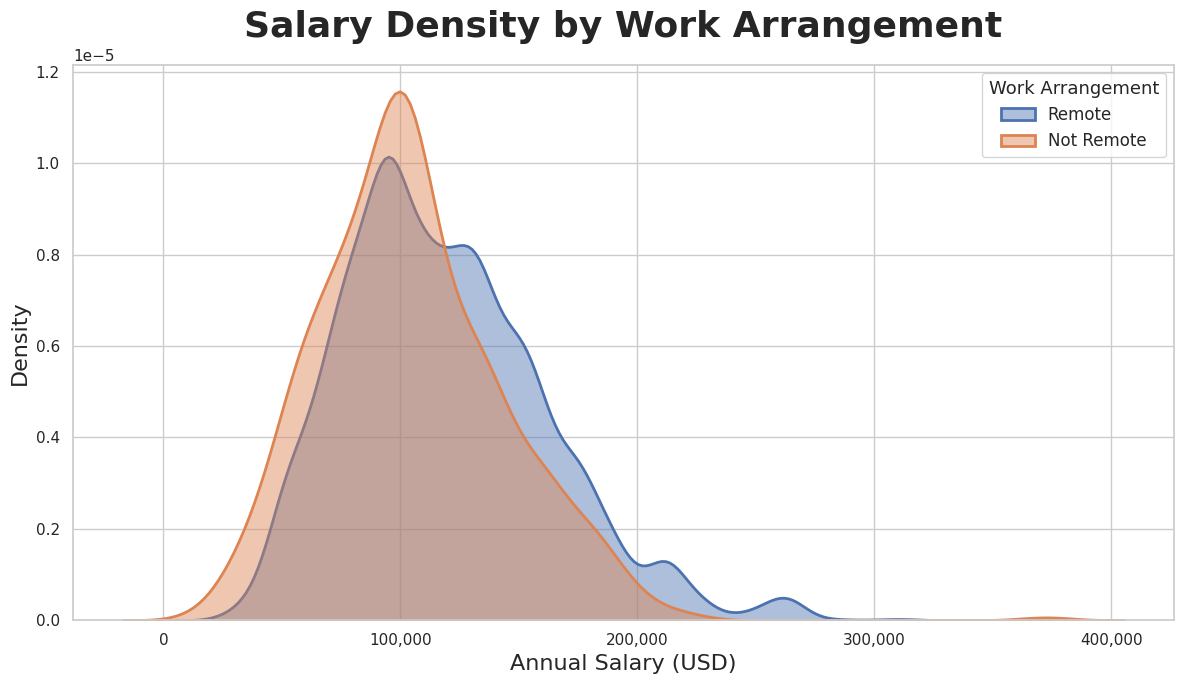

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

sns.set_theme(style="whitegrid")

plt.figure(figsize=(9,5))

# Make a clean copy for remote analysis
df_remote = df.copy()

# Keep only rows where remote type is known
df_remote = df_remote[df_remote["REMOTE_TYPE_NAME"].notna()]

# Ensure SALARY is numeric
df_remote["SALARY"] = pd.to_numeric(df_remote["SALARY"], errors="coerce")
df_remote = df_remote[df_remote["SALARY"].notna()]


sns.kdeplot(
    df_remote[df_remote["REMOTE_TYPE_NAME"] == "Remote"]["SALARY"],
    fill=True, alpha=0.45, linewidth=2,
    label="Remote"
)

sns.kdeplot(
    df_remote[df_remote["REMOTE_TYPE_NAME"] == "Not Remote"]["SALARY"],
    fill=True, alpha=0.45, linewidth=2,
    label="Not Remote"
)


plt.title(
    "Salary Density by Work Arrangement",
    fontsize=26,
    weight="bold",
    loc="center",    
    pad=20           
)

plt.xlabel("Annual Salary (USD)", fontsize=16)
plt.ylabel("Density", fontsize=16)

plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{int(x):,}")
)

plt.legend(title="Work Arrangement", fontsize=12, title_fontsize=13, loc="upper right")
plt.tight_layout()
plt.show()



The salary density chart highlights clear differences between remote and non-remote work arrangements. Both groups peak around the $90,000–$110,000 range, indicating that this salary band represents the most common earning level across the dataset. However, the remote group exhibits a noticeably wider and longer right tail, with salaries extending well beyond $250,000 and reaching above $350,000. In contrast, non-remote salaries taper off much earlier, with far fewer roles exceeding $200,000.

This distribution suggests that remote positions are more heavily represented in high-paying fields such as technology, data science, cybersecurity, and other specialized knowledge-based roles. The broader spread of remote salaries also indicates greater variability, meaning remote work encompasses both mid-level and highly senior or niche positions. Meanwhile, the tighter clustering of non-remote salaries reflects more uniform pay structures often found in operational, in-person, or location-dependent industries.

Overall, the density comparison demonstrates that while typical salaries are similar between the two groups, remote jobs offer significantly higher earning potential, aligning with current labor market trends favoring flexible, high-skill digital roles.

## 4. Salary Differences Across U.S. States
*This section visualizes how average salaries vary geographically across the United States.*


In [ ]:
import plotly.express as px
import pandas as pd

df_map = df.copy()
df_map = df_map[df_map["STATE_NAME"].notna()]
df_map["SALARY"] = pd.to_numeric(df_map["SALARY"], errors="coerce")
df_map = df_map[df_map["SALARY"].notna()]
df_map["STATE_NAME"] = df_map["STATE_NAME"].str.strip()

state_abbrev = {
    'Alabama': 'AL','Alaska': 'AK','Arizona': 'AZ','Arkansas': 'AR','California': 'CA','Colorado': 'CO',
    'Connecticut': 'CT','Delaware': 'DE','Florida': 'FL','Georgia': 'GA','Hawaii': 'HI','Idaho': 'ID',
    'Illinois': 'IL','Indiana': 'IN','Iowa': 'IA','Kansas': 'KS','Kentucky': 'KY','Louisiana': 'LA',
    'Maine': 'ME','Maryland': 'MD','Massachusetts': 'MA','Michigan': 'MI','Minnesota': 'MN',
    'Mississippi': 'MS','Missouri': 'MO','Montana': 'MT','Nebraska': 'NE','Nevada': 'NV','New Hampshire': 'NH',
    'New Jersey': 'NJ','New Mexico': 'NM','New York': 'NY','North Carolina': 'NC','North Dakota': 'ND',
    'Ohio': 'OH','Oklahoma': 'OK','Oregon': 'OR','Pennsylvania': 'PA','Rhode Island': 'RI',
    'South Carolina': 'SC','South Dakota': 'SD','Tennessee': 'TN','Texas': 'TX','Utah': 'UT','Vermont': 'VT',
    'Virginia': 'VA','Washington': 'WA','West Virginia': 'WV','Wisconsin': 'WI','Wyoming': 'WY'
}

df_map["STATE_ABB"] = df_map["STATE_NAME"].map(state_abbrev)
df_map = df_map[df_map["STATE_ABB"].notna()]

state_salary = (
    df_map.groupby('STATE_ABB')['SALARY']
    .mean()
    .reset_index()
)

fig = px.choropleth(
    state_salary,
    locations="STATE_ABB",
    locationmode="USA-states",
    color="SALARY",
    color_continuous_scale="Viridis",
    scope="usa",
    labels={"SALARY": "Salary (USD)"},
    title="Mean Annual Salary by U.S. State"
)

#fig.show()

fig.write_html("plots/salary_map.html", include_plotlyjs="cdn")

The choropleth map highlights clear regional patterns in average annual salaries across the United States. States on the West Coast, including California and Washington, consistently exhibit some of the highest salary levels in the country, often surpassing $120,000. The Northeast shows a similar trend, with Massachusetts, New York, and New Jersey standing out as strong economic hubs where salaries remain well above the national average. These states benefit from dense concentrations of high-skill industries such as technology, finance, biotechnology, and professional services.

In contrast, much of the South and parts of the Midwest display lower mean salary ranges, typically between $105,000 and $115,000. States such as West Virginia, Kentucky, and Louisiana fall toward the lower end of the spectrum, reflecting differences in industry mix, labor market dynamics, and cost of living. While these regions may offer more affordable living conditions, the aggregate salary levels highlight persistent regional disparities tied to economic development patterns.

Overall, the map underscores how geographic location continues to play a significant role in shaping earning potential. Areas with strong innovation sectors, major metropolitan centers, and diversified labor markets tend to command higher compensation, while regions with more traditional or resource-based economies show comparatively modest salary levels. 